<a href="https://colab.research.google.com/github/JosephBless/Deep-Learning-Colab/blob/main/Chap_4%EF%BC%9A%E9%87%91%E8%9E%8D%E6%8C%87%E6%A8%99%E8%A8%88%E7%AE%97%E8%88%87%E7%AD%96%E7%95%A5%E9%96%8B%E7%99%BC%E5%9F%BA%E7%A4%8E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

在這一節中，我們將結合金融指標計算和策略開發的基礎知識。首先，我們會計算基本的金融指標，如收益率、累計收益率和波動率，並深入理解夏普比率和最大回撤等風險調整指標。接著，我們將運用這些指標來設計簡單的交易策略，例如均線交叉策略，並了解策略開發的流程與注意事項。

In [ ]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2024-09-19 08:41:40--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 142.251.111.100, 142.251.111.102, 142.251.111.101, ...
Connecting to drive.google.com (drive.google.com)|142.251.111.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2024-09-19 08:41:40--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.167.132, 2607:f8b0:4004:c1d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.167.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M   116MB/s    in 0.2s    

2024-09-19 

### **一、金融指標計算**

#### **1. 收益率（Returns）**

- **每日收益率**：

  收益率是衡量資產價格變化的基本指標。計算公式為：

  $$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

  其中，$ P_t $ 是第 $ t $ 天的收盤價，$ R_t $ 是第 $ t $ 天的收益率。

- **累計收益率**：

  累計收益率表示資產在一段時間內的總收益，計算公式為：

  $$
  CR = \prod_{t=1}^{T} (1 + R_t) - 1
  $$

#### **2. 波動率（Volatility）**

波動率衡量資產收益的變動程度，通常使用收益率的標準差來表示。

$$
\sigma = \sqrt{\frac{1}{T-1} \sum_{t=1}^{T} (R_t - \bar{R})^2}
$$

其中，$ \bar{R} $ 是平均收益率。

#### **3. 夏普比率（Sharpe Ratio）**

夏普比率衡量單位風險下的超額收益，計算公式為：

$$
SR = \frac{\bar{R} - R_f}{\sigma}
$$

其中，$ R_f $ 是無風險利率。

#### **4. 最大回撤（Max Drawdown）**

最大回撤衡量投資組合從最高點到最低點的最大損失，計算公式為：

$$
MDD = \max_{t \in [0,T]} \left( \frac{H_t - P_t}{H_t} \right)
$$

其中，$ H_t $ 是截至第 $ t $ 天的歷史最高價。

#### **5. Python實現**

以下是使用Python計算這些指標的範例：



In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf

# 獲取數據
data = yf.download('AAPL', start='2020-01-01', end='2021-01-01')
prices = data['Adj Close']

# 計算每日收益率
returns = prices.pct_change().dropna()

# 累計收益率
cumulative_return = (1 + returns).prod() - 1

# 波動率
volatility = returns.std()

# 假設無風險利率為0.01
risk_free_rate = 0.01

# 夏普比率
sharpe_ratio = (returns.mean() - risk_free_rate/252) / returns.std() * np.sqrt(252)

# 最大回撤
rolling_max = prices.cummax()
drawdown = (prices - rolling_max) / rolling_max
max_drawdown = drawdown.min()

print("\n")
print(f'累計收益率: {cumulative_return:.2%}')
print(f'波動率: {volatility:.2%}')
print(f'夏普比率: {sharpe_ratio:.2f}')
print(f'最大回撤: {max_drawdown:.2%}')


[*********************100%***********************]  1 of 1 completed



累計收益率: 78.24%
波動率: 2.94%
夏普比率: 1.45
最大回撤: -31.43%


### **二、策略開發基礎**

#### **1. 策略開發流程**

1. **策略構思**：根據市場觀察或金融理論，提出交易策略的基本概念。

2. **數據收集與處理**：獲取相關的市場數據，並進行清洗和預處理。

3. **策略實現**：使用編程語言（如Python）將策略邏輯編碼。

4. **回測**：在歷史數據上測試策略的表現。

5. **評估與優化**：使用金融指標評估策略，並進行參數調整。

6. **實時交易**：在真實市場中部署策略，並進行監控。

#### **2. 均線交叉策略示例**

**策略概念**：

- **短期均線**（如10日移動平均線）代表近期價格趨勢。
- **長期均線**（如50日移動平均線）代表長期價格趨勢。
- 當短期均線上穿長期均線時，產生買入信號；反之，產生賣出信號。

**Python實現**：

[*********************100%***********************]  1 of 1 completed
<ipython-input-7-e9ceff40a000>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'][10:] = np.where(data['SMA_short'][10:] > data['SMA_long'][10:], 1, 0)


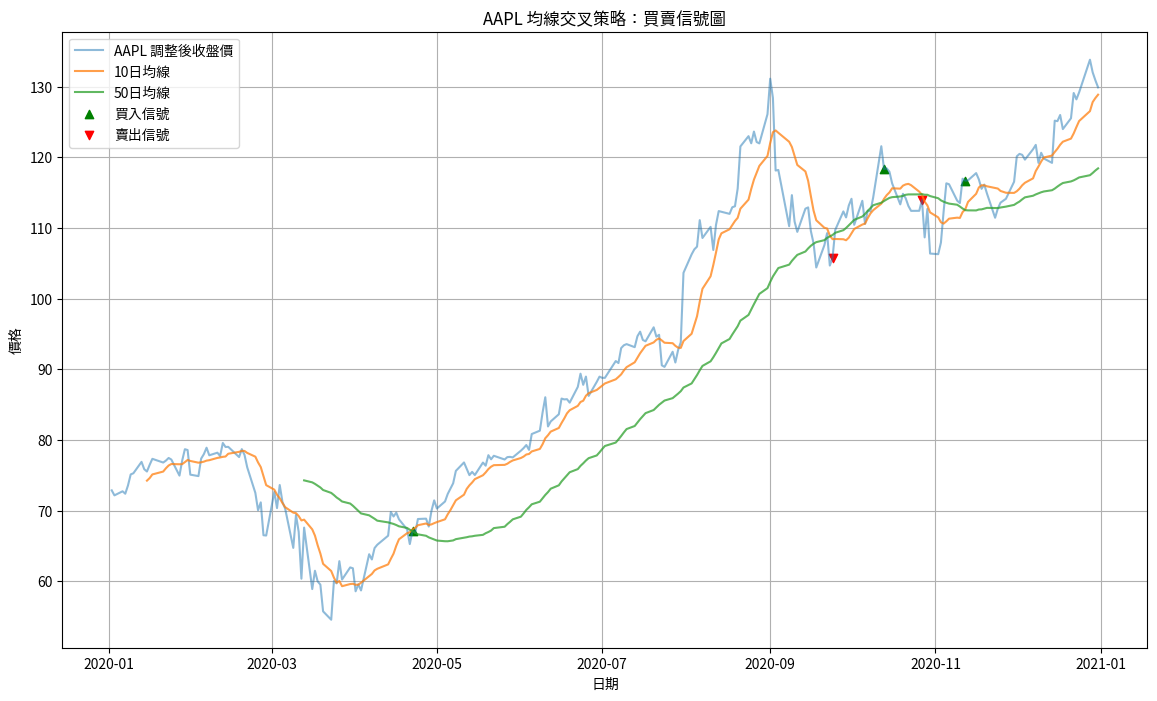

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 獲取數據
data = yf.download('AAPL', start='2020-01-01', end='2021-01-01')

# 計算短期和長期移動平均線
data['SMA_short'] = data['Adj Close'].rolling(window=10).mean()
data['SMA_long'] = data['Adj Close'].rolling(window=50).mean()

# 產生交易信號
data['Signal'] = 0
data['Signal'][10:] = np.where(data['SMA_short'][10:] > data['SMA_long'][10:], 1, 0)

# 建立持倉狀態
data['Position'] = data['Signal'].diff()

# 標示買入和賣出點
buy_signals = data[data['Position'] == 1]
sell_signals = data[data['Position'] == -1]

# 繪製價格、均線、買賣信號圖
plt.figure(figsize=(14, 8))
plt.plot(data['Adj Close'], label='AAPL 調整後收盤價', alpha=0.5)
plt.plot(data['SMA_short'], label='10日均線', alpha=0.75)
plt.plot(data['SMA_long'], label='50日均線', alpha=0.75)

# 繪製買入信號（綠色點）
plt.scatter(buy_signals.index, buy_signals['Adj Close'], marker='^', color='green', label='買入信號', alpha=1)

# 繪製賣出信號（紅色點）
plt.scatter(sell_signals.index, sell_signals['Adj Close'], marker='v', color='red', label='賣出信號', alpha=1)

plt.title('AAPL 均線交叉策略：買賣信號圖')
plt.xlabel('日期')
plt.ylabel('價格')
plt.legend()
plt.grid(True)
plt.show()


**策略評估**：

- **收益對比**：比較策略的累計收益率與基準指數（如標普500指數）的累計收益率。

- **風險指標**：計算策略的波動率、夏普比率和最大回撤。

**注意事項**：

- **滑點和交易成本**：在真實交易中，需要考慮買賣差價和手續費對策略收益的影響。

- **過擬合**：避免在歷史數據上過度調整策略參數，以免在未來市場中表現不佳。

- **風險管理**：設置止損和止盈點，控制單筆交易的風險。

#### **3. 策略優化**

- **參數調整**：測試不同的移動平均線期間組合，尋找最佳表現。

- **加入過濾器**：如交易量、其他技術指標（RSI、MACD）等，提高信號的可靠性。

- **多資產組合**：將策略應用於不同的資產，分散風險。

---

### **三、綜合應用：從指標到策略**

將金融指標計算與策略開發結合，能夠更全面地評估和優化交易策略。

#### **1. 使用夏普比率優化策略**

- **目標**：在多組參數下，選擇夏普比率最高的策略。

- **方法**：

  - 遍歷不同的短期和長期均線組合。
  - 對每組組合計算策略的夏普比率。
  - 選擇夏普比率最高的組合。

**示例代碼**：

In [ ]:
short_windows = [5, 10, 15]
long_windows = [20, 50, 100]

best_sharpe = -np.inf
best_params = (None, None)

for short_window in short_windows:
    for long_window in long_windows:
        if short_window >= long_window:
            continue
        data['SMA_short'] = data['Adj Close'].rolling(window=short_window).mean()
        data['SMA_long'] = data['Adj Close'].rolling(window=long_window).mean()
        data['Signal'] = 0
        data['Signal'][long_window:] = np.where(data['SMA_short'][long_window:] > data['SMA_long'][long_window:], 1, 0)
        data['Position'] = data['Signal'].diff()
        data['Strategy_Returns'] = data['Adj Close'].pct_change() * data['Position'].shift(1)
        strategy_returns = data['Strategy_Returns'].dropna()
        sharpe_ratio = (strategy_returns.mean() - risk_free_rate/252) / strategy_returns.std() * np.sqrt(252)
        if sharpe_ratio > best_sharpe:
            best_sharpe = sharpe_ratio
            best_params = (short_window, long_window)

print(f'最佳參數組合: 短期均線={best_params[0]}, 長期均線={best_params[1]}, 夏普比率={best_sharpe:.2f}')

最佳參數組合: 短期均線=15, 長期均線=20, 夏普比率=1.46


<ipython-input-4-11b7484aed47>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'][long_window:] = np.where(data['SMA_short'][long_window:] > data['SMA_long'][long_window:], 1, 0)
<ipython-input-4-11b7484aed47>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'][long_window:] = np.where(data['SMA_short'][long_window:] > data['SMA_long'][long_window:], 1, 0)
<ipython-input-4-11b7484aed47>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retur